# Análisis de Centralidad con PageRank

## Medidas de Centralidad y Algoritmos de Grafos

### Objetivo

Aplicar el algoritmo PageRank sobre el grafo de FraudeLink utilizando
Neo4j Graph Data Science (GDS), con el objetivo de identificar y priorizar
cuentas o entidades estructuralmente relevantes dentro de la red.

El resultado será un ranking de nodos que pueda apoyar la investigación
de posibles patrones de fraude.

## Instalacion de GDS

In [14]:
%pip install graphdatascience pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [15]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


## Importacion de librerias

In [16]:
import os 
import pandas as pd
import matplotlib.pyplot as plt

import graphdatascience as gds

## Establecer conexion a Neo4j

In [17]:
import os
from dotenv import load_dotenv
from graphdatascience import GraphDataScience

load_dotenv()

NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")

gds = GraphDataScience(
    NEO4J_URI,
    auth=(NEO4J_USERNAME, NEO4J_PASSWORD)
)

prueba = gds.run_cypher("RETURN 1 AS prueba")

print("Conexión establecida con Neo4j")
print(prueba)

Conexión establecida con Neo4j
   prueba
0       1


In [18]:
resultado = gds.run_cypher("RETURN 1 AS prueba")
resultado

,prueba
0,1


In [19]:
print("Version GDS:", gds.server_version())

Version GDS: 2.13.13


## Verificar nodos y relaciones

### Contar nodos

In [20]:
query_nodos = """
MATCH (n)
RETURN labels(n)[0] AS tipo, count(*) AS cantidad
ORDER BY cantidad DESC
"""

nodos_df = gds.run_cypher(query_nodos)
nodos_df 

,tipo,cantidad
0,Cuenta,5000
1,Cliente,4000
2,Dispositivo,2000
3,IP,1000
4,Comercio,500


### Contar relaciones

In [21]:
query_relaciones = """
MATCH ()-[r]->()
RETURN type(r) AS relacion, count(*) AS cantidad
ORDER BY cantidad DESC
"""

relaciones_df = gds.run_cypher(query_relaciones)
relaciones_df

,relacion,cantidad
0,TRANSFIERE_A,30007
1,PAGA_EN,15000
2,USA_DISPOSITIVO,8000
3,CONECTA_DESDE,8000
4,POSEE,5000


### Carga y verificacion de datos

Se importan los nodos y relaciones (datos) a la instancia de docker de la base de datos.

In [22]:
import subprocess
import sys
from pathlib import Path

conteo = gds.run_cypher("""
MATCH (n)
WITH count(n) AS nodos
MATCH ()-[r]->()
RETURN nodos, count(r) AS relaciones
""")

nodos = int(conteo.loc[0, "nodos"])
relaciones = int(conteo.loc[0, "relaciones"])

if nodos == 12500 and relaciones == 66007:
    print("Los datos ya están cargados.")
else:
    print("Datos no cargados o incompletos. Ejecutando importar_datos.py...")

    script = Path.cwd() / "importar_datos.py"

    if not script.exists():
        raise FileNotFoundError(f"No se encontró {script}")

    subprocess.run(
        [sys.executable, str(script)],
        check=True
    )

    print("Datos importados correctamente.")

Los datos ya están cargados.


In [23]:
graph_name = "fraudelink_graph"

if gds.graph.exists(graph_name):
    gds.graph.drop(graph_name)

G, metadata = gds.graph.project.native(
    graph_name,
    ["Cliente", "Cuenta", "Dispositivo", "IP", "Comercio"],
    {
        "POSEE": {"orientation": "NATURAL"},
        "USA_DISPOSITIVO": {"orientation": "NATURAL"},
        "CONECTA_DESDE": {"orientation": "NATURAL"},
        "TRANSFIERE_A": {"orientation": "NATURAL"},
        "PAGA_EN": {"orientation": "NATURAL"}
    }
)

print("Nodos proyectados:", G.node_count())
print("Relaciones proyectadas:", G.relationship_count())

Nodos proyectados: 12500
Relaciones proyectadas: 66007


## PageRank

In [24]:
pagerank_df = gds.page_rank.stream(G)

pagerank_df = pagerank_df.sort_values(by='score', ascending=False)

pagerank_df.head(10)

,nodeId,score
12473,12473,1.572722
12089,12089,1.357296
12297,12297,1.352704
12009,12009,1.331242
12180,12180,1.324986
12217,12217,1.297741
12236,12236,1.283469
12279,12279,1.278129
12164,12164,1.277857
12407,12407,1.265983


In [25]:
query_pagerank = """
CALL gds.pageRank.stream('fraudelink_graph')
YIELD nodeId, score

WITH gds.util.asNode(nodeId) AS node, score

RETURN
    labels(node)[0] AS tipo,
    coalesce(node.cliente_id, node.cuenta_id, node.dispositivo_id, node.ip_address, node.comercio_id) AS id,
    score AS pagerank

ORDER BY pagerank DESC
LIMIT 20
"""

pagerank_general = gds.run_cypher(query_pagerank)
pagerank_general

,tipo,id,pagerank
0,Comercio,COM00474,1.572722
1,Comercio,COM00090,1.357296
2,Comercio,COM00298,1.352704
3,Comercio,COM00010,1.331242
4,Comercio,COM00181,1.324986
5,Comercio,COM00218,1.297741
6,Comercio,COM00237,1.283469
7,Comercio,COM00280,1.278129
8,Comercio,COM00165,1.277857
9,Comercio,COM00408,1.265983


In [26]:
query_cuentas = """
CALL gds.pageRank.stream('fraudelink_graph')
YIELD nodeId, score

WITH gds.util.asNode(nodeId) AS node, score

WHERE node:Cuenta

RETURN
    node.cuenta_id AS cuenta_id,
    score AS pagerank

ORDER BY pagerank DESC
LIMIT 10
"""

ranking_cuentas = gds.run_cypher(query_cuentas)
ranking_cuentas

,cuenta_id,pagerank
0,CTA00235,0.815413
1,CTA03424,0.788266
2,CTA03050,0.718827
3,CTA03735,0.699315
4,CTA00716,0.691299
5,CTA02111,0.671860
6,CTA03173,0.649577
7,CTA01719,0.647717
8,CTA02241,0.645838
9,CTA02773,0.645603


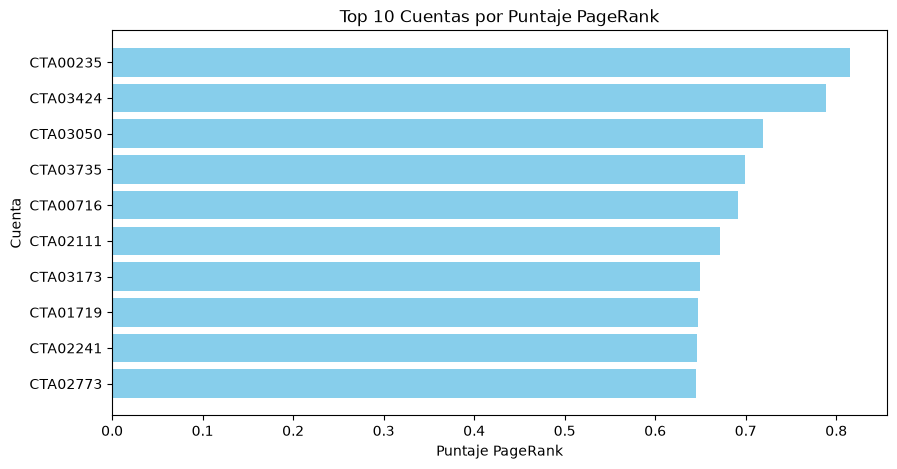

In [27]:
import matplotlib.pyplot as plt

top10 = ranking_cuentas.head(10)

plt.figure(figsize=(10, 5))

plt.barh(top10['cuenta_id'], top10['pagerank'], color='skyblue')

plt.xlabel('Puntaje PageRank')
plt.ylabel('Cuenta')
plt.title('Top 10 Cuentas por Puntaje PageRank')

plt.gca().invert_yaxis()  # Invertir el eje y para mostrar la cuenta con mayor PageRank en la parte superior

plt.show()

## Análisis matemático de PageRank

PageRank asigna a cada nodo una puntuación de importancia según las conexiones que reciba cada nodo y la importancia que generan esas mismas coenxiones.

A continuación se muestra la fórmula simplificada:

$$
PR(v) = (1-d) + d \sum_{u \in In(v)} \frac{PR(u)}{L(u)}
$$

donde:

- \(PR(v)\) es el puntaje PageRank del nodo \(v\).
- \(d\) es el factor de amortiguamiento el cual indica cuánto peso se da a las conexiones del grafo frente a una probabilidad base de salto aleatorio. En PageRank suele usarse \(d = 0.85\).
- \(In(v)\) es el conjunto de nodos que tienen una relación dirigida hacia \(v\).
- \(PR(u)\) representa la importancia del nodo origen.
- \(L(u)\) es la cantidad de relaciones salientes del nodo \(u\).

El cálculo se realiza de forma iterativa. En cada iteración, cada nodo distribuye parte de su importancia entre los nodos a los que apunta.
Las puntuaciones se actualizan hasta que los cambios entre iteraciones son suficientemente pequeños.

* Neo4j usa por defecto un factor de amortiguamiento de 0.85, y PageRank considera tanto la cantidad de relaciones entrantes como la importancia de los nodos desde donde vienen esas relaciones.

### Ejemplo del caso

Sea por ejemplo que se tienen las siguientes cuentas (nodos) que apuntan a otras:

```text
CTA001 → CTA003
CTA002 → CTA003
CTA004 → CTA003
CTA005 → CTA003
```

Entonces `CTA003` recibe una importancia de 4 nodos.

No obstante, PageRank no se basa en que tenga 4 conexiones y que gane automaticamente, sino cada nodo que apunta a `CTA003` le transfiere una parte de su propio PageRank. 


Entonces sea por ejemplo que `CTA001` tiene un PageRank alto y pocas relaciones salientes, una mayor parte de su importancia llega a `CTA003`.

Conceptualmente hablando:

$$
\text{Aporte de CTA001} =
\frac{PR(CTA001)}{L(CTA001)}
$$

Por ejemplo, si hipotéticamente:

$$
PR(CTA001) = 1.2
$$

y la cuenta tiene 2 relaciones salientes:

$$
\frac{1.2}{2} = 0.6
$$

Entonces, CTA001 aporta aproximadamente **0.6** antes de aplicar el factor de amortiguamiento.

En cambio, si otra cuenta tiene:

$$
PR(CTA002) = 1.2
$$

pero posee 12 relaciones salientes:

$$
\frac{1.2}{12} = 0.1
$$

su aporte individual es mucho menor.

Por eso, **no todas las conexiones tienen el mismo efecto dentro de PageRank**.



## Justificación en la investigación de fraude

PageRank es útil en FraudeLink porque permite identificar nodos que ocupan
una posición estructuralmente importante dentro de la red.

Una cuenta puede obtener un PageRank elevado cuando recibe conexiones desde
varios nodos que, a su vez, también tienen importancia dentro del grafo.

Esto permite priorizar cuentas que podrían funcionar como puntos de
concentración, intermediarios relevantes o destinos recurrentes dentro de
una red de relaciones.

Por ejemplo, si varias cuentas estructuralmente relevantes transfieren hacia
una misma cuenta, esa cuenta puede acumular un PageRank mayor y aparecer en
las primeras posiciones del ranking.

Esto no demuestra fraude por sí solo, pero permite reducir el espacio de
búsqueda y priorizar qué cuentas deberían analizarse con mayor detalle.


**En nuestra implementación, el score representa relevancia estructural dentro de la red completa de FraudeLink. Por eso una cuenta puede ganar importancia no solo por transferencias, sino también por sus conexiones con dispositivos, IP, clientes y comercios.**

# Detección de comunidades

Después de identificar cuentas relevantes mediante PageRank, se analiza la estructura del grafo para detectar grupos de cuentas que se encuentran fuertemente relacionadas entre sí.

Para este análisis se utiliza el algoritmo **Louvain**, disponible en Neo4j Graph Data Science (GDS).

Louvain busca dividir el grafo en comunidades donde exista una mayor cantidad de conexiones internas que conexiones hacia otros grupos.

En el contexto de FraudeLink, estas comunidades pueden representar conjuntos de cuentas que realizan transferencias entre sí de forma frecuente o que forman estructuras de interacción relevantes para una investigación.

La pertenencia a una comunidad no implica fraude automáticamente. El objetivo es reducir el espacio de búsqueda e identificar grupos que puedan analizarse posteriormente junto con otros indicadores de riesgo.

## Proyección del grafo para Louvain

Para ejecutar Louvain se crea una nueva proyección del grafo en memoria utilizando únicamente los nodos `Cuenta` y las relaciones `TRANSFIERE_A`.

Esta proyección es independiente de la utilizada anteriormente para PageRank, por lo que no modifica ni elimina el análisis de centralidad.

Las relaciones se proyectan con orientación `UNDIRECTED`, ya que para la detección de comunidades interesa principalmente determinar qué cuentas se encuentran conectadas entre sí.

Aunque en la base de datos una transferencia tiene una dirección real, para este análisis se considera la existencia de una conexión entre ambas cuentas independientemente de quién envió o recibió el dinero.

In [28]:
community_graph_name = "fraudelink_comunidades"

if gds.graph.exists(community_graph_name):
    gds.graph.drop(community_graph_name)

G_comunidades, metadata_comunidades = gds.graph.project.native(
    community_graph_name,
    ["Cuenta"],
    {
        "TRANSFIERE_A": {
            "orientation": "UNDIRECTED"
        }
    }
)

print("Nodos proyectados:", G_comunidades.node_count())
print("Relaciones proyectadas:", G_comunidades.relationship_count())

Nodos proyectados: 5000
Relaciones proyectadas: 60014


## Ejecución del algoritmo Louvain

Una vez creada la proyección, se aplica el algoritmo Louvain.

El algoritmo comienza considerando cada nodo como una comunidad independiente.

Posteriormente intenta mover los nodos entre comunidades buscando aumentar la modularidad del grafo.

Cuando ya no puede mejorar significativamente la modularidad, agrupa los nodos de cada comunidad y repite el proceso sobre una versión reducida del grafo.

El resultado final asigna un identificador de comunidad (`communityId`) a cada cuenta.

In [29]:
louvain_df = gds.louvain.stream(G_comunidades)

louvain_df.head(10)

 Louvain: 100%|██████████| 100.0/100 [00:05<00:00, 17.04%/s, status: FINISHED]                                                                   


,nodeId,communityId,intermediateCommunityIds
0,4000,3558,None
1,4001,3558,None
2,4002,3558,None
3,4003,4001,None
4,4004,4637,None
5,4005,3627,None
6,4006,4541,None
7,4007,801,None
8,4008,4001,None
9,4009,4541,None


## Identificación de las cuentas por comunidad

El resultado directo de GDS utiliza identificadores internos de nodos.

Para facilitar la interpretación, se convierte cada `nodeId` al nodo real de Neo4j y se obtiene la propiedad `cuenta_id`.

De esta forma es posible observar directamente qué cuentas pertenecen a cada comunidad detectada.

In [30]:
query_comunidades = """
CALL gds.louvain.stream('fraudelink_comunidades')
YIELD nodeId, communityId

WITH gds.util.asNode(nodeId) AS cuenta, communityId

RETURN
    cuenta.cuenta_id AS cuenta_id,
    communityId

ORDER BY communityId, cuenta_id
"""

comunidades_df = gds.run_cypher(query_comunidades)

comunidades_df.head(20)

,cuenta_id,communityId
0,CTA00017,703
1,CTA00025,703
2,CTA00044,703
3,CTA00049,703
4,CTA00051,703
5,CTA00057,703
6,CTA00060,703
7,CTA00099,703
8,CTA00111,703
9,CTA00114,703


## Ranking de comunidades

Una vez asignada una comunidad a cada cuenta, se agrupan los resultados para determinar cuáles comunidades contienen una mayor cantidad de cuentas.

Este ranking permite identificar rápidamente los grupos más grandes detectados por Louvain.

Una comunidad grande no implica necesariamente mayor riesgo, pero permite localizar estructuras con una concentración importante de cuentas relacionadas.

Estas comunidades pueden analizarse posteriormente junto con información adicional como PageRank, ciclos de transferencias, montos, dispositivos compartidos o direcciones IP.

In [31]:
query_ranking_comunidades = """
CALL gds.louvain.stream('fraudelink_comunidades')
YIELD nodeId, communityId

WITH gds.util.asNode(nodeId) AS cuenta, communityId

RETURN
    communityId,
    count(*) AS cantidad_cuentas,
    collect(cuenta.cuenta_id)[0..10] AS cuentas_ejemplo

ORDER BY cantidad_cuentas DESC
LIMIT 10
"""

ranking_comunidades = gds.run_cypher(query_ranking_comunidades)

ranking_comunidades

,communityId,cantidad_cuentas,cuentas_ejemplo
0,1043,412,"[CTA00019, CTA00022, CTA00030, CTA00040, CTA00..."
1,1307,359,"[CTA00049, CTA00090, CTA00100, CTA00101, CTA00..."
2,698,326,"[CTA00031, CTA00070, CTA00086, CTA00095, CTA00..."
3,3251,302,"[CTA00005, CTA00010, CTA00011, CTA00025, CTA00..."
4,2635,282,"[CTA00118, CTA00119, CTA00138, CTA00187, CTA00..."
5,732,268,"[CTA00053, CTA00057, CTA00072, CTA00082, CTA00..."
6,4684,255,"[CTA00009, CTA00024, CTA00047, CTA00052, CTA00..."
7,4273,252,"[CTA00016, CTA00023, CTA00033, CTA00037, CTA00..."
8,4019,250,"[CTA00004, CTA00007, CTA00012, CTA00017, CTA00..."
9,1159,244,"[CTA00036, CTA00039, CTA00044, CTA00060, CTA00..."


## Visualización de las comunidades principales

Para facilitar la comparación entre las comunidades detectadas, se representan gráficamente las diez comunidades con mayor cantidad de cuentas.

El eje horizontal indica la cantidad de cuentas y el eje vertical identifica la comunidad asignada por Louvain.

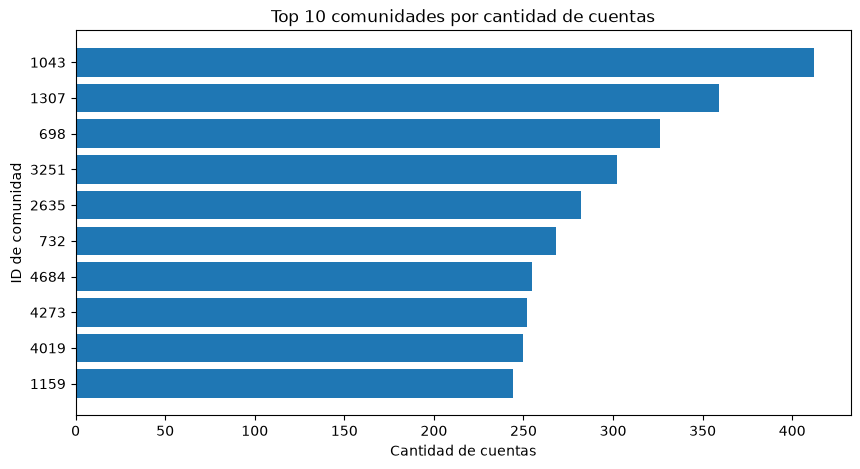

In [32]:
top_comunidades = ranking_comunidades.head(10)

plt.figure(figsize=(10, 5))

plt.barh(
    top_comunidades["communityId"].astype(str),
    top_comunidades["cantidad_cuentas"]
)

plt.xlabel("Cantidad de cuentas")
plt.ylabel("ID de comunidad")
plt.title("Top 10 comunidades por cantidad de cuentas")

plt.gca().invert_yaxis()

plt.show()

## Interpretación en FraudeLink

En FraudeLink, una comunidad representa un grupo de cuentas que presenta una mayor concentración de transferencias internas.

Este tipo de agrupación puede resultar útil en investigaciones de fraude porque permite detectar conjuntos de cuentas que interactúan principalmente entre sí.

Por ejemplo, una comunidad podría contener cuentas que participan repetidamente en transferencias circulares o que funcionan como intermediarios dentro de una misma red.

Sin embargo, pertenecer a una comunidad no demuestra comportamiento fraudulento.

Louvain se utiliza como una herramienta para localizar grupos estructuralmente relacionados que posteriormente pueden analizarse utilizando otras señales de riesgo.

## Relación entre PageRank y Louvain

PageRank y Louvain analizan características diferentes del grafo.

**PageRank** responde a la pregunta:

> ¿Qué cuentas tienen una mayor importancia estructural dentro de la red?

**Louvain** responde a la pregunta:

> ¿Qué cuentas forman grupos fuertemente relacionados entre sí?

Por ejemplo, una cuenta puede presentar un PageRank alto debido a que recibe conexiones desde cuentas importantes.

Si además esa cuenta pertenece a una comunidad con una alta concentración de transferencias internas, puede convertirse en un punto de interés adicional para la investigación.

Por lo tanto, ambos algoritmos son complementarios:

- PageRank prioriza nodos individuales.
- Louvain identifica redes o grupos.
- La combinación permite pasar de la investigación de una cuenta específica al análisis de la estructura completa que la rodea.